# Von Daten zu Insights: Data Science & AI

Analysiere und visualisiere Krankenkassen-Daten mit Python und trainieren und evaluiere dein erstes Machine Learning Modell. Entdecke, wie faszinierend Data Science und Künstliche Intelligenz sind und wie du mit unserem flexiblen Studienkonzept deine eigene Lernreise gestalten kannst.

### Imports

- **pandas** ist eine Bibliothek zum Einlesen, Transformieren und Visualisieren von Daten. Standardmässig wird es mit **pd** abgekürzt.
- **matplotlib.pyplot** unterstützt pandas beim Visualiseren und wird oft mit **plt** abgekürzt.
- **scikit-learn**  / sklearn ist eine Machine Learning Bibliothek, welche Werkzeug für Machine Learning Modelle bietet.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
## Modell-Metriken
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
## Verschiedene Modelle
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

## Daten analysieren und visualisieren

In [2]:
data = pd.read_csv("krankenkasse.csv")
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


### Analysieren mit neuen Features und Filtern

In [3]:
## Neues Feature definieren: Gesundheitskategorie
data["risk"] = ["yes" if smoker == "yes" and bmi >= 35 else "no" for smoker, bmi in zip(data["smoker"], data["bmi"])]

## Filtern
high_risk = data[data["risk"] == "yes"]

## Spalten wählen
high_risk = high_risk[["age", "bmi", "charges"]]
high_risk

,age,bmi,charges
14,27,42.13,39611.75770
19,30,35.30,36837.46700
29,31,36.30,38711.00000
30,22,35.60,35585.57600
34,28,36.40,51194.55914
...,...,...,...
1240,52,41.80,47269.85400
1241,64,36.96,49577.66240
1284,61,36.30,47403.88000
1288,20,39.40,38344.56600


### Daten visualiseren

Es gibt verschiedene Arten von Plots und Parametern, je nach Plot unterscheiden sich die Parameter. In der [Pandas Dokumentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html) findet ihr mehr Infos dazu. ChatGPT kann natürlich auch immer weiterhelfen.

Colormaps: https://matplotlib.org/stable/users/explain/colors/colormaps.html

<Axes: ylabel='Frequency'>

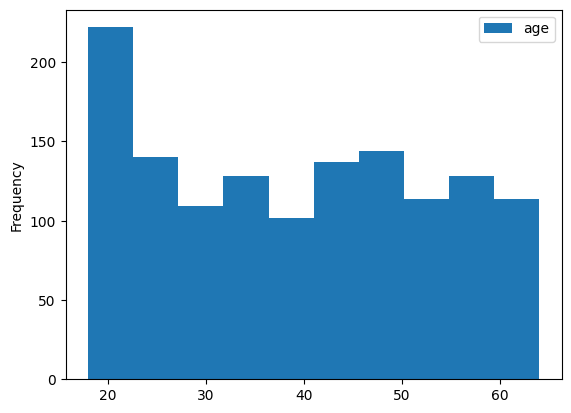

In [4]:
## Verteilung anschauen
data.plot(kind="hist", y="age", bins=10)

<Axes: xlabel='age', ylabel='charges'>

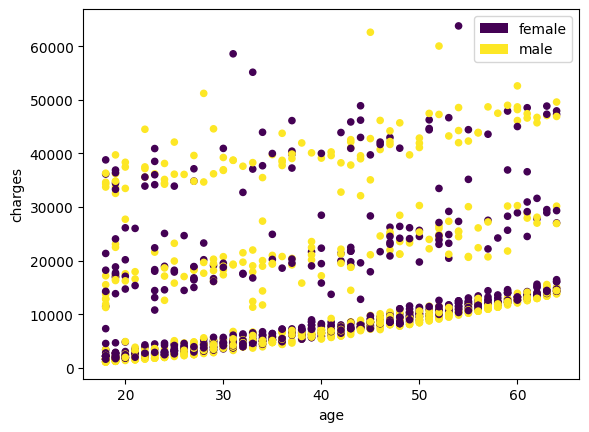

In [10]:
## Scatterplot mit Alter und Kosten
data.plot(x="age", y="charges", c="sex", kind="scatter")

## Modell trainieren

### Target und Features definieren

Das Target ist die Variable, welches unser Modell berechnen soll, das Ziel sozusagen.

Features sind die Variablen, welches unser Modell in der Berechnung nutzen kann.

**Wichtig: Kategorische Variablen wie "Sex" (female, male) müssen in Zahlen umgewandelt werden, um als Feature oder Target genutzt werden zu können.**

In [ ]:
target = data["charges"]
features = data[["sex", "age", "bmi"]]

## Variablen umwandeln
features["sex"] = [1 if sex == "male" else 0 for sex in features["sex"]]
print(features.head())

   sex  age     bmi
0    0   19  27.900
1    1   18  33.770
2    1   28  33.000
3    1   33  22.705
4    1   32  28.880


### Modell trainieren und auswerten

In [13]:
model = LinearRegression()
model.fit(features, target)

data["predictions"] = model.predict(features)
data

,age,sex,bmi,children,smoker,region,charges,risk,predictions
0,19,female,27.900,0,yes,southwest,16884.92400,no,6771.970348
1,18,male,33.770,1,no,southeast,1725.55230,no,9795.881940
2,28,male,33.000,3,no,southeast,4449.46200,no,11975.544229
3,33,male,22.705,0,no,northwest,21984.47061,no,9819.497403
4,32,male,28.880,0,no,northwest,3866.85520,no,11598.843370
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,no,16660.749297
1334,18,female,31.920,0,no,northeast,2205.98080,no,7845.477059
1335,18,female,36.850,0,no,southeast,1629.83350,no,9460.227654
1336,21,female,25.800,0,no,southwest,2007.94500,no,6570.518494


In [18]:
MAE = mean_absolute_error(data["charges"], data["predictions"])
MSE = mean_squared_error(data["charges"], data["predictions"])
RMSE = root_mean_squared_error(data["charges"], data["predictions"])
R2 = r2_score(data["charges"], data["predictions"])

print("The lower the MAE, MSE and RMSE, the better the model's predictions are.")
print(f"MAE: {MAE}")
print(f"MSE: {MSE}")
print(f"RMSE: {RMSE}")
print("\n")
print("R2 ranges from 0 to 1, where a higher value indicates a better fit of the model to the data.")
print("It's the percentage of the variance in the target variable that is explained by the features.")
print(f"R2: {R2}")

The lower the MAE, MSE and RMSE, the better the model's predictions are.
MAE: 8997.275079168969
MSE: 128919821.43984821
RMSE: 11354.286478676157


R2 ranges from 0 to 1, where a higher value indicates a better fit of the model to the data.
It's the percentage of the variance in the target variable that is explained by the features.
R2: 0.1202580343975943
